In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
import warnings

warnings.filterwarnings('ignore')

In [2]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'   Training samples: {X_train.shape[0]}')
print(f'   Test samples:     {X_test.shape[0]}\n')

   Training samples: 8000
   Test samples:     2000



In [3]:
sgd_clf = SGDClassifier(
    loss='log_loss',      # Use 'log' for scikit-learn < 1.1
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

In [4]:
sgd_clf.fit(X_train_scaled, y_train)
y_pred = sgd_clf.predict(X_test_scaled)

print(f'   Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred))

   Accuracy: 0.8230

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1001
           1       0.87      0.76      0.81       999

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000



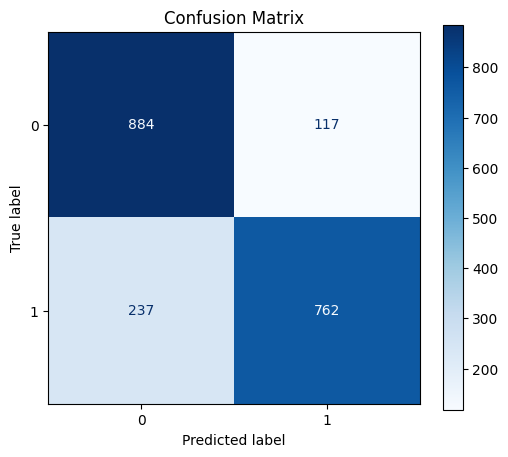

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sgd_clf.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

In [6]:
sgd_online = SGDClassifier(loss='log_loss', random_state=42)
chunk_size = 500

for i in range(0, len(X_train_scaled), chunk_size):
    X_chunk = X_train_scaled[i:i+chunk_size]
    y_chunk = y_train[i:i+chunk_size]
    # Note: classes must be provided on the FIRST partial_fit call
    sgd_online.partial_fit(X_chunk, y_chunk, classes=np.unique(y_train))

y_pred_online = sgd_online.predict(X_test_scaled)
print(f'   Online Learning Accuracy: {accuracy_score(y_test, y_pred_online):.4f}')

   Online Learning Accuracy: 0.7735


In [7]:
param_grid = [
    {'loss': ['hinge', 'log_loss', 'modified_huber'], 
     'penalty': ['l2', 'l1'], 
     'alpha': [0.0001, 0.001, 0.01]},
    {'loss': ['log_loss'], 
     'penalty': ['elasticnet'], 
     'alpha': [0.0001, 0.001, 0.01], 
     'l1_ratio': [0.15, 0.5, 0.85]}
]

grid_search = GridSearchCV(
    SGDClassifier(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f'   Best Parameters: {grid_search.best_params_}')
print(f'   Best CV Accuracy: {grid_search.best_score_:.4f}\n')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print(f'   Test Accuracy (Best Model): {accuracy_score(y_test, y_pred_best):.4f}')

   Best Parameters: {'alpha': 0.001, 'loss': 'hinge', 'penalty': 'l1'}
   Best CV Accuracy: 0.8229

   Test Accuracy (Best Model): 0.8205


In [13]:
sgd_converge = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-4)

classes = np.unique(y_train)

loss_curve = []
epochs = 50

# 4. Custom training loop to mimic a loss curve
for epoch in range(epochs):
    # Train on the data for one epoch
    sgd_converge.partial_fit(X_train, y_train, classes=classes)
    
    # Predict probabilities to calculate log loss
    y_prob = sgd_converge.predict_proba(X_train)
    epoch_loss = log_loss(y_train, y_prob)
    
    # Store the loss
    loss_curve.append(epoch_loss)


sgd_converge.fit(X_train_scaled, y_train)


SGDClassifier(loss='log_loss', random_state=42, tol=0.0001)

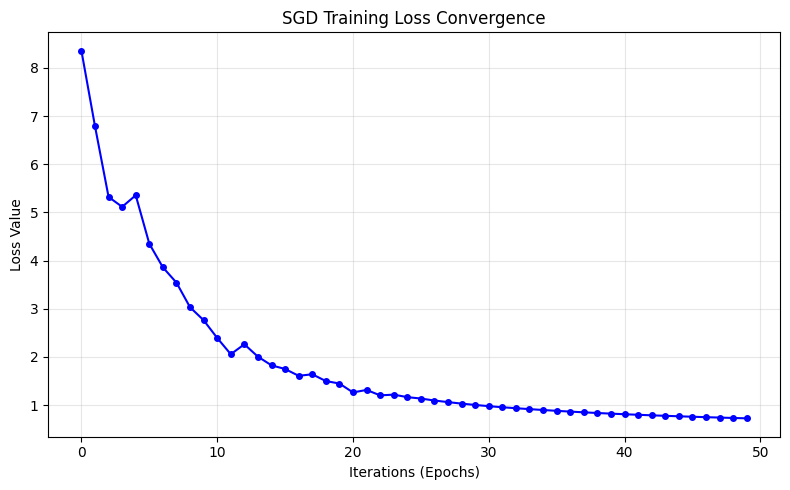

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(loss_curve, marker='o', linestyle='-', color='b', markersize=4)
plt.title('SGD Training Loss Convergence')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()